# Heston's stochastic volatility model

Consider Heston's stochastic volatility model:

\begin{cases}
dS_t = \mu S_t dt + \sqrt{\nu_t} S_t dB_t^1,\\
d\nu_t = k(\theta - \nu_t) dt + \eta \sqrt{\nu_t} dB_t^2,
\end{cases}

where $B^1$ and $B^2$ are correlated Brownian motions, defined as:

\begin{cases} 
B_t^1 =\sqrt{1-\rho^2}W_t^1 + \rho W_t^2, \\
B_t^2 = W_t^2,
\end{cases}

where $W^1$ and $W^2$ are standard Brownian motions. The dynamics of the underlying asset are expressed under the martingale measure $\mathbb{Q}$, therefore $\mu$ represents the market risk-free rate.

In [3]:
import numpy as np
from scipy import stats
from scipy import linalg
from scipy import optimize
import matplotlib.pyplot as plt

In [4]:
# Parameters of the Heston stochastic volatility model:

S0 = 1.0        # initial price of the underlying asset
mu = 0.03       # drift of the underlying asset, corresponds to the risk-free rate
k = 5.0         # speed of mean reversion of the variance
v0 = 0.04       # initial variance
theta = 0.04    # long-term variance
eta = 0.3       # volatility of the variance
rho = -0.7      # correlation between the two Brownian motions B^1, B^2
T = 0.5         # maturity in years
dt = 1.0 / 252  # delta_t, daily upgrade

# array of Call option strikes
KK = np.arange(start=0.5, stop=1.5 + 1e-10, step=0.1)

This choice of parameters satisfies the Feller condition, since:

In [6]:
2*k*theta > eta**2

True

Thus, the solution to the volatility SDE remains positive and is well-defined:
$$
\nu_t > 0 \quad\text{almost surely,}\quad \text{for all }t\geq 0.
$$

We write the dynamics of the log-price of the underlying asset. Letting $X_t=\log(S_t)$, by Itô's formula we have:
\begin{align}
dX_t &= \frac{1}{S_t} dS_t - \frac{1}{2S_t^2}d\braket{S}_t\\
&= \mu dt + \sqrt{\nu_t}dB_t^1 - \frac{1}{2S_t^2} \nu_t S_t^2 d\braket{B^1}_t \\
&= \mu dt + \sqrt{\nu_t}\left(\sqrt{1-\rho^2} dW_t^1 + \rho dW_t^2\right) - \frac{1}{2} \nu_t d\braket{\sqrt{1-\rho^2} W^1+\rho W^2}_t \\
&= \mu dt + \sqrt{(1-\rho^2)\nu_t} dW_t^1 + \rho \sqrt{\nu_t} dW_t^2 - \frac{1}{2} \nu_t \left( (1-\rho^2)dt + \rho^2 dt\right) \\
&= \left(\mu - \frac{1}{2} \nu_t \right) dt + \sqrt{(1-\rho^2)\nu_t} dW_t^1 + \rho \sqrt{\nu_t} dW_t^2  \\ 
\end{align}

By simulating the log-price dynamics, we transform the initial SDE into a new SDE where the coefficients do not depend on the price, thereby reducing the approximation error and making the method more stable.

We write the Euler discretization for the log-price and the volatility:
$$
\begin{cases}
X_{t+\Delta_t} = X_t + \left(\mu - \frac{1}{2} \nu_t \right) \Delta_t + \sqrt{(1-\rho^2)\nu_t} \Delta W_t^1 + \rho \sqrt{\nu_t} \Delta W_t^2, \quad\quad\quad\Delta W_t^1,\Delta W_t^2\sim\mathcal{N}(0,\Delta_t),\\
\nu_{t+\Delta_t} = \nu_t + k(\theta - \nu_t) \Delta_t + \eta \sqrt{\nu_t} \Delta W_t^2,
\end{cases}
$$

Even though the Feller condition is satisfied, when we discretize the process it is possible for $\nu_t$ to become negative, causing issues when evaluating the square root. For this reason, we implement the following control on volatility, known as the Full Truncation Scheme, which is one of the best-performing methods according to the literature:
$$
\begin{cases}
\nu_{pos} = \max{\{\nu_t, 0\}} \\
X_{t+\Delta_t} = X_t + \left(\mu - \frac{1}{2} \nu_{pos} \right) \Delta_t + \sqrt{(1-\rho^2)\nu_{pos}} \Delta W_t^1 + \rho \sqrt{\nu_{pos}} \Delta W_t^2, \\
\nu_{t+\Delta_t} = \nu_t + k(\theta - \nu_{pos}) \Delta_t + \eta \sqrt{\nu_{pos}} \Delta W_t^2,
\end{cases}
$$

With this solution, we set the variance value to zero whenever it becomes negative before proceeding to the calculation of the next time step.

### Code

In [9]:
# Vectorized version for European Call option pricing
# K can be an array

def heston_call(S0, mu, k, v0, theta, eta, rho, K, T, m, dt):
    tt = np.arange(start=0, stop=T + 1e-10, step=dt)
    n = len(tt)
    
    X0 = np.log(S0)
    X = np.zeros(shape=(n, m))
    X[0, :] = X0
    
    v = np.zeros(shape=(n, m))
    v[0, :] = v0
    
    for i in range(n-1):
        dW1 = stats.norm.rvs(size=m) * np.sqrt(dt)
        dW2 = stats.norm.rvs(size=m) * np.sqrt(dt)

        # Implementing the Full Truncation Scheme for negative variance
        v_pos = np.maximum(v[i, :], 0)
        X[i+1, :] = X[i, :] + (mu - 0.5 * v_pos) * dt + np.sqrt((1 - rho**2) * v_pos) * dW1 + rho * np.sqrt(v_pos) * dW2
        v[i+1, :] = v[i, :] + k * (theta - v_pos) * dt + eta * np.sqrt(v_pos) * dW2
    
    S = np.exp(X)

    # Adjusting the shape of K
    K_array = np.asarray(K)
    if K_array.ndim > 0:
        # Transforming K into a column vector
        K_array = K_array[:, np.newaxis]
        
    payoff = np.exp(-np.multiply(mu, T)) * (S[-1, :] - K_array).clip(min=0)
    
    # To compute the expected value, we calculate the sample mean
    # of the payoffs along the last axis (of size m)
    # since np.shape(payoff) = (K_array.ndim, m)
    return {
        'price': payoff.mean(axis=-1),  
        'S': S,
        'X': X,
        'v': v,
    }

### Plot of the underlying paths in the Heston model

In [11]:
n_sim = 500
tt = np.arange(start=0, stop=T + 1e-10, step=dt)

results = heston_call(S0, mu, k, v0, theta, eta, rho, KK, T, n_sim, dt)
S_heston = results['S']
X_heston = results['X']
v_heston = results['v']

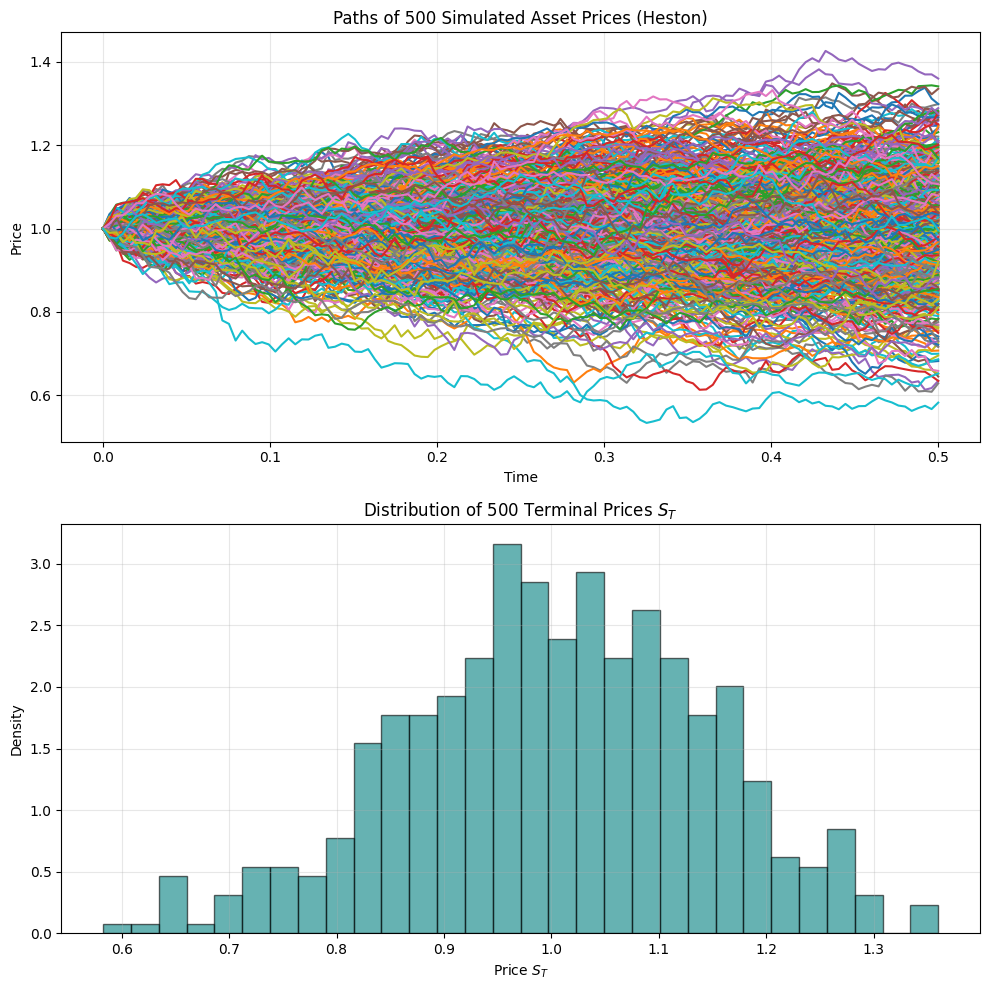

In [12]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))

# Underlying asset paths
ax[0].plot(tt, S_heston)
ax[0].set_title(f"Paths of {n_sim} Simulated Asset Prices (Heston)")
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Price')
ax[0].grid(True, alpha=0.3)

# Frequency histogram of prices at maturity T
ax[1].hist(S_heston[-1,:], bins=30, density=True, alpha=0.6, color='teal', edgecolor='black')
ax[1].set_title(f"Distribution of {n_sim} Terminal Prices $S_T$")
ax[1].set_xlabel('Price $S_T$')
ax[1].set_ylabel('Density')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The histogram exhibits a negative skewness in the empirical frequency distribution of terminal prices, characterized by a fatter left tail. This asymmetry in the price distribution stems from the negative correlation between the Brownian motions governing the asset price and its variance dynamics. Specifically, when the asset price drops, volatility tends to increase, thereby enhancing the probability of extreme negative returns.

### Plot of Variance Paths in the Heston Model

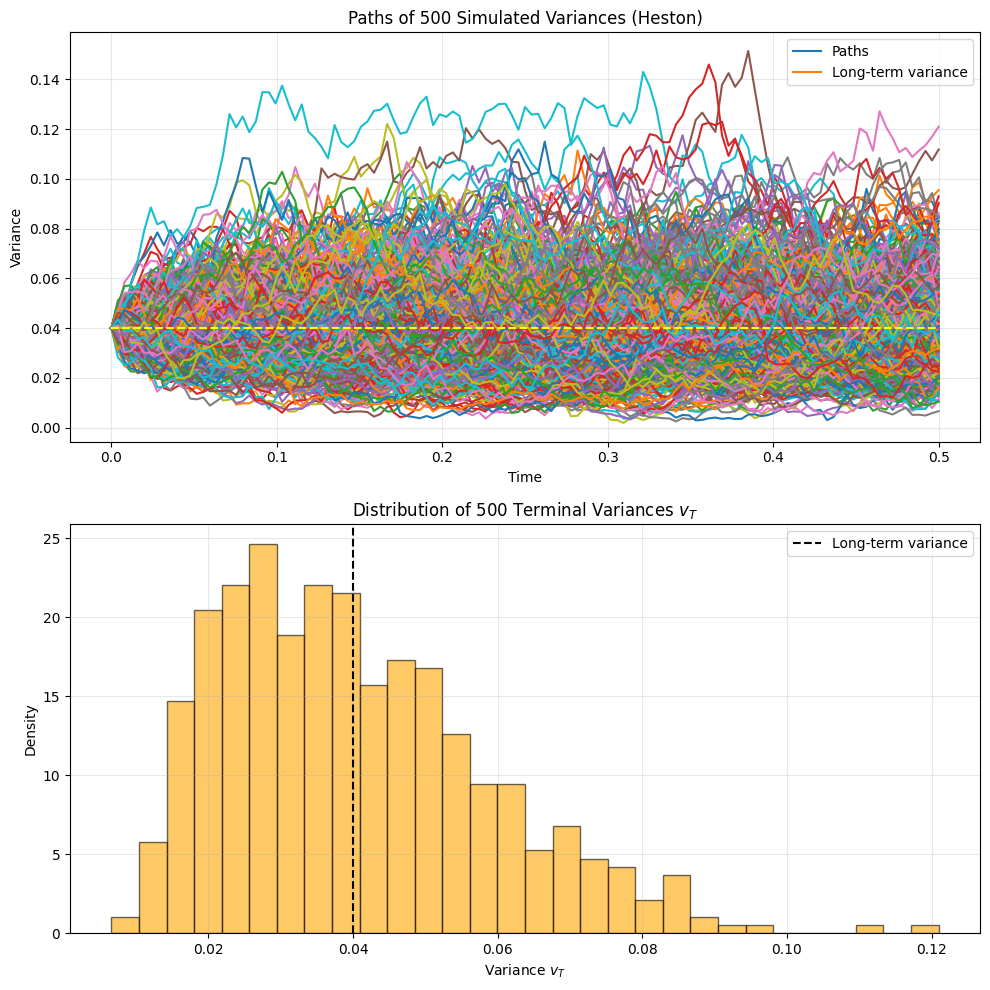

In [15]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))

# Variance paths
ax[0].plot(tt, v_heston)
ax[0].plot(tt, theta * np.ones_like(tt), label="Long-term variance", color='yellow', linestyle='--')
ax[0].set_title(f"Paths of {n_sim} Simulated Variances (Heston)")
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Variance')
ax[0].legend(['Paths', 'Long-term variance'], loc='best')
ax[0].grid(True, alpha=0.3)

# Frequency histogram of variance values at maturity T
ax[1].hist(v_heston[-1,:], bins=30, density=True, alpha=0.6, color='orange', edgecolor='black')
ax[1].axvline(theta, color='black', linestyle='--', label='Long-term variance')
ax[1].set_title(f"Distribution of {n_sim} Terminal Variances $v_T$")
ax[1].set_xlabel('Variance $v_T$')
ax[1].set_ylabel('Density')
ax[1].legend(['Long-term variance'], loc='best')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Distribution of Terminal Log-Prices of the Underlying Asset

The distribution of the terminal log-prices of the underlying asset is not normally distributed, unlike in the Black-Scholes model. Instead, it exhibits a leptokurtic distribution.

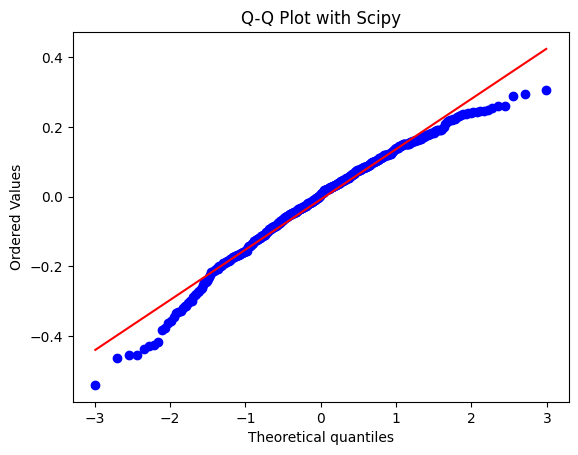

In [17]:
stats.probplot(X_heston[-1,:], dist="norm", plot=plt)

plt.title("Q-Q Plot with Scipy")
plt.show()

### Plot of European Call Option Prices Against Strike $K$

We compute the European Call option prices using the Heston model for all strike values contained in the array `KK`.

In [19]:
m = 1000000        # number of Monte Carlo simulations

results = heston_call(S0, mu, k, v0, theta, eta, rho, KK, T, m, dt)
price_heston = results['price']

print(f"{'Strike K':<11} | {'Heston Call Price':<10}")
print("="*35)

for i in range(len(KK)):
    print(f"{KK[i]:<10.2f} | {price_heston[i]:<15.6f}")

Strike K    | Heston Call Price
0.50       | 0.507604       
0.60       | 0.409174       
0.70       | 0.311342       
0.80       | 0.216383       
0.90       | 0.130407       
1.00       | 0.063326       
1.10       | 0.022671       
1.20       | 0.005478       
1.30       | 0.000842       
1.40       | 0.000081       
1.50       | 0.000006       


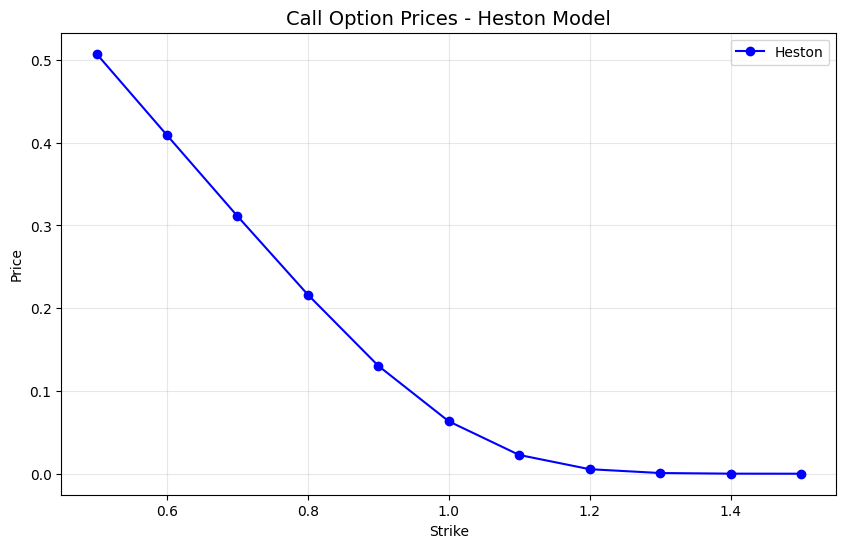

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(KK, price_heston, marker='o', linestyle='-', color='b', label='Heston')
ax.set_title('Call Option Prices - Heston Model', fontsize=14)
ax.set_xlabel('Strike')
ax.set_ylabel('Price')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

As is well known from economic theory, the plot clearly highlights that the Call option price is a decreasing function of the strike price.

The trend does not follow a straight line but rather describes a convex curve, whose convexity becomes more pronounced around $K=1.0$, where the strike price matches the current value of the underlying asset (meaning the option is at-the-money).

Subsequently, for strike prices above $1.0$, the option moves out-of-the-money, and its price decreases significantly. However, due to the stochastic volatility and the negative correlation coefficient ($\rho=-0.7$), the Heston model generates an underlying asset distribution characterized by heavy tails. Consequently, even options with deeply out-of-the-money strikes retain a small positive value. This correctly reflects the hedging cost against rare but severe market shocks, which the standard Black-Scholes model would fail to capture.

# Implied Volatility

In the Black-Scholes model, the price of a European Call option can be calculated using the following closed-form formula:
$$
BS(S_0, K, T, r, \sigma)=S_0\Phi(d_+) - K e^{-rT}\Phi(d_-)
$$
where
$$
d_\pm=\frac{\log(\frac{S_0}{K})+rT}{\sigma\sqrt{T}}\pm\frac{1}{2}\sigma\sqrt{T}
$$
and $\Phi$ denotes the cumulative distribution function (CDF) of a standard normal distribution. We can implement this formula computationally by defining:
\begin{align}
s &\coloneqq\sigma\sqrt{T},\\
KrT &\coloneqq Ke^{-rT}, \\
d_+ &\coloneqq\frac{\log(\frac{S_0}{KrT})}{s}+\frac{s}{2},\\
d_- &\coloneqq d_+-s, \\
BS(S_0, K, T, r, \sigma) &=S_0\Phi(d_+) - KrT\Phi(d_-).
\end{align}

In [24]:
def bs_call(S0, K, T, r, vol):
    with np.errstate(divide='ignore', invalid='ignore'):
        s = vol*np.sqrt(T)
        KrT = np.exp(-np.multiply(r,T))*K
        d1 = np.log(S0/KrT)/s + s/2
        d2 = d1 - s
        C = S0*stats.norm.cdf(d1) - KrT*stats.norm.cdf(d2)
        C = np.where(np.isnan(C), 0.0, C)
    return C

## Method 1: SciPy's $\textit{fsolve}$ Function

We compute the implied volatility using the `scipy.optimize.fsolve` function. This approach has the advantage of being highly efficient, but it has the disadvantage of not being vectorizable over independent arrays.

In [26]:
def implied_volatility(price, S0, K, T, r):
    # Find the volatility that zeroes out the difference between the BS price and the Heston price
    def obj_fun(x):
        return price - bs_call(S0, K, T, r, x)

    X0 = [0.1, 0.3, 0.5, 1.0, 3.0]  # Set of initial volatility guess values
    
    for x0 in X0:
        x, _, solved, _ = optimize.fsolve(obj_fun, x0, full_output=True, xtol=1e-8)
        if solved == 1:
            return x[0]
    return np.nan # Returns NaN if no solution is found

In [27]:
IV_heston = []

print(f"{'Strike K':<11} | {'Heston Implied Volatility (fsolve)':<10}")
print("="*50)
for i in range(len(KK)):
    IV_heston.append(implied_volatility(price_heston[i], S0=S0, K=KK[i], T=T, r=mu))
    print(f" {KK[i]:<10.2f} | {IV_heston[i]:<15.6f}")
    
IV_heston = np.array(IV_heston)

Strike K    | Heston Implied Volatility (fsolve)
 0.50       | 0.363807       
 0.60       | 0.287897       
 0.70       | 0.249225       
 0.80       | 0.228765       
 0.90       | 0.212807       
 1.00       | 0.198616       
 1.10       | 0.186004       
 1.20       | 0.175069       
 1.30       | 0.166042       
 1.40       | 0.158826       
 1.50       | 0.154360       


## Method 2: Newton's Method

We compute the implied volatility using the `scipy.optimize.newton` function, which implements Newton's method. This approach offers the advantage of being vectorizable and requires the analytical expression of Vega (the first derivative of the Call option price with respect to $\sigma$), which can be expressed in closed form for the Black-Scholes model. However, it carries the disadvantage that for large values of $\sigma$, Vega can be extremely close to zero, which slows down the convergence of the method.

In the Black-Scholes model, Vega is given by:
$$
\mathcal{V}=\frac{\partial BS}{\partial\sigma}(S_0, K, T, r, \sigma)=S_0\sqrt{T}\Phi'(d_+),
$$
where $\Phi'(x)$ denotes the probability density function (PDF) of a standard normal distribution.

In [30]:
import warnings
from scipy.optimize import newton

def implied_volatility(price, S0, K, T, r):
    
    def obj_fun(vol, price, S0, K, T, r):
        return bs_call(S0, K, T, r, vol) - price
    
    def bs_vega(vol, price, S0, K, T, r):
        d1 = (np.log(S0/K) + (r + 0.5*vol**2)*T)/(vol*np.sqrt(T))
        vega = S0*stats.norm.pdf(d1)*np.sqrt(T)
        return np.where(vega < 1e-10, 1e-10, vega)
        
    vol_iniziale = [0.1, 0.3, 0.5, 1.0, 3.0]
    iv = np.full_like(K, np.nan, dtype=float)
    
    for v in vol_iniziale:
        # If all elements have converged, break the loop
        if not np.isnan(iv).any():
            break
            
        initial_guess = np.full_like(K, v, dtype=float)
        
        # Ignore NumPy and SciPy warnings if Newton's method fails to converge
        with warnings.catch_warnings(), np.errstate(all='ignore'):
            warnings.simplefilter("ignore", RuntimeWarning)
            res = newton(func=obj_fun, x0=initial_guess, fprime=bs_vega, args=(price, S0, K, T, r), tol=1e-8, maxiter=200, disp=False)
            
        errore = np.abs(bs_call(S0, K, T, r, res) - price)
          
        # A value is considered valid where the error is minimized, volatility is positive, and no solution was previously found
        valido = (errore < 1e-6) & (res > 0) & np.isnan(iv)
            
        # Update iv only where the result is valid
        iv[valido] = res[valido]
            
    return iv

In [31]:
IV_heston = implied_volatility(price_heston, S0=S0, K=KK, T=T, r=mu)

print(f"{'Strike K':<11} | {'Heston Implied Volatility (Newton)':<10}")
print("="*50)
for i in range(len(KK)):
    print(f" {KK[i]:<10.2f} | {IV_heston[i]:<15.6f}")

Strike K    | Heston Implied Volatility (Newton)
 0.50       | 0.363807       
 0.60       | 0.287897       
 0.70       | 0.249225       
 0.80       | 0.228765       
 0.90       | 0.212807       
 1.00       | 0.198616       
 1.10       | 0.186004       
 1.20       | 0.175069       
 1.30       | 0.166042       
 1.40       | 0.158826       
 1.50       | 0.154360       


### Sanity Check: Implied Volatility of the Black-Scholes Model

We compute the implied volatility of the Black-Scholes model and verify that it is flat; therefore, the model fails to reproduce the volatility smile.
We compute the European Call option price using the Black-Scholes model, setting the constant volatility equal to the long-term volatility level of the Heston model:
$$
\sigma = \sqrt{\theta}.
$$

In [33]:
price_bs = bs_call(S0=S0, K=KK, T=T, r=mu, vol=np.sqrt(theta))

print(f"{'Strike K':<11} | {'Black-Scholes Call Price':<10}")
print("="*40)

for i in range(len(KK)):
    print(f" {KK[i]:<10.2f} | {price_bs[i]:<15.6f}")

Strike K    | Black-Scholes Call Price
 0.50       | 0.507444       
 0.60       | 0.408935       
 0.70       | 0.310578       
 0.80       | 0.214293       
 0.90       | 0.127993       
 1.00       | 0.063710       
 1.10       | 0.026119       
 1.20       | 0.008914       
 1.30       | 0.002589       
 1.40       | 0.000656       
 1.50       | 0.000149       


In [34]:
IV_bs = implied_volatility(price_bs, S0=S0, K=KK, T=T, r=mu) 

print(f"{'Strike K':<11} | {'Black-Scholes Implied Volatility':<10}")
print("="*50)
for i in range(len(KK)):
    print(f" {KK[i]:<10.2f} | {IV_bs[i]:<15.2f}")

Strike K    | Black-Scholes Implied Volatility
 0.50       | 0.20           
 0.60       | 0.20           
 0.70       | 0.20           
 0.80       | 0.20           
 0.90       | 0.20           
 1.00       | 0.20           
 1.10       | 0.20           
 1.20       | 0.20           
 1.30       | 0.20           
 1.40       | 0.20           
 1.50       | 0.20           


### Plot of the Heston Model Volatility Smile

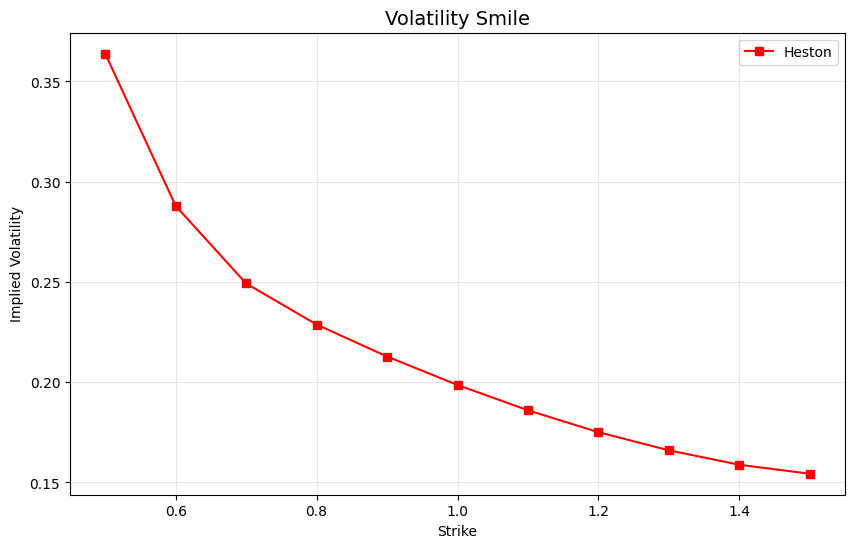

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(KK, IV_heston, marker='s', linestyle='-', color='r', label='Heston')
ax.set_title('Volatility Smile', fontsize=14)
ax.set_xlabel('Strike')
ax.set_ylabel('Implied Volatility')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

The implied volatility plot confirms that the Heston model, unlike the Black-Scholes model, is capable of reproducing the volatility smile empirically observed in market prices and successfully captures the skewness of returns. In particular, the slope of the curve is consistent with the correlation parameter $\rho=-0.7$: the volatility skew assigns higher volatility to lower strike prices, as the model allocates greater probability to extreme negative events.
Therefore, the smile reflects the tendency of volatility to increase during market downturns.

### Comparison: Heston vs Black-Scholes Volatility Smile

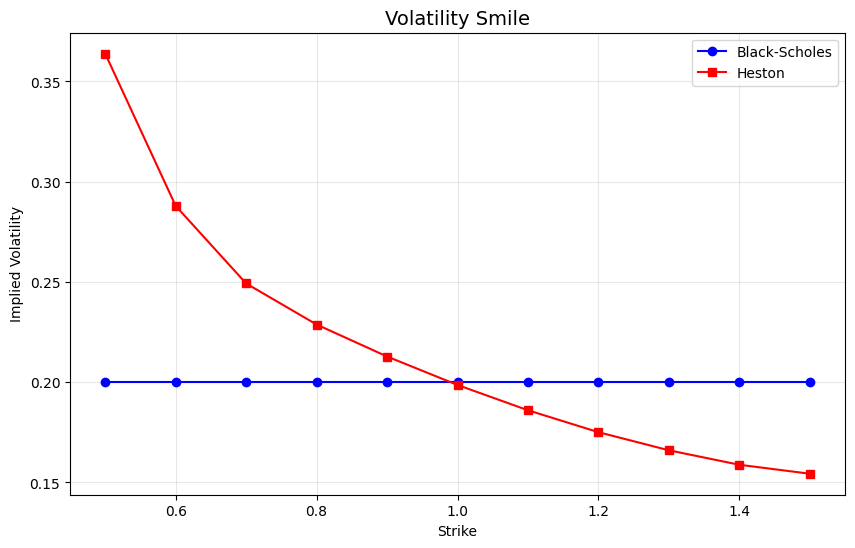

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(KK, IV_bs, marker='o', linestyle='-', color='b', label='Black-Scholes')
ax.plot(KK, IV_heston, marker='s', linestyle='-', color='r', label='Heston')
ax.set_title('Volatility Smile', fontsize=14)
ax.set_xlabel('Strike')
ax.set_ylabel('Implied Volatility')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()